# osmFISH TonT: REVISE sc-SVC cluster reconstruction

This notebook reproduces TACCO's base single-molecule annotation and
`tacco_seg`, aggregates molecules into TonT segmented cells, and runs the
REVISE Xenium-style `sc-SVC` cluster route separately for Pyramidal and
Inhibitory cells. The temporary 10 µm shifted bins are annotation internals,
not REVISE reconstruction units.

TACCO source: [rendered notebook](https://simonwm.github.io/tacco/notebooks/osmFISH_single_molecule_annotation.html)
and immutable preparation code `simonwm/tacco_examples@ed61ddc584be72217fe83d33b8995589264efd50`.


In [1]:
import importlib.metadata
import json
import os
from pathlib import Path
import shutil
import subprocess
import sys

for key in (
    "OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS",
    "NUMEXPR_NUM_THREADS", "VECLIB_MAXIMUM_THREADS", "NUMBA_NUM_THREADS",
):
    os.environ[key] = "1"
os.environ["PYTHONHASHSEED"] = "42"
os.environ["MPLBACKEND"] = "Agg"
os.environ.pop("NUMBA_DISABLE_JIT", None)

import anndata as ad
from IPython.display import Image, Markdown, display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def locate_repo_root():
    current = Path.cwd().resolve()
    for candidate in (current, *current.parents):
        if (candidate / "reconstruct.py").is_file() and (candidate / "reproduce/case/tacco").is_dir():
            return candidate
    raise RuntimeError(f"Cannot locate REVISE repository from {current}")

REPO_ROOT = locate_repo_root()
TACCO_CASE_DIR = REPO_ROOT / "reproduce/case/tacco"
sys.path.insert(0, str(REPO_ROOT))
sys.path.insert(0, str(TACCO_CASE_DIR))

from notebook_utils import (
    assigned_labels,
    audit_table,
    data_root,
    independent_umap,
    independent_umaps,
    load_json,
    manifest_from_output,
    plot_independent_panels,
    sha256_file,
)

DATA_ROOT = data_root()
PREPARE_SCRIPT = TACCO_CASE_DIR / "prepare_cases.py"
FORCE_RECONSTRUCTION = os.environ.get("REVISE_TACCO_FORCE_RUN", "0") == "1"

RUN_ENV = os.environ.copy()
RUN_ENV["PYTHONPATH"] = str(REPO_ROOT)
RUN_ENV["MPLBACKEND"] = "Agg"
RUN_ENV.pop("NUMBA_DISABLE_JIT", None)

environment = pd.DataFrame(
    [
        ("python", sys.version.split()[0]),
        ("executable", sys.executable),
        ("tacco", importlib.metadata.version("tacco")),
        ("scanpy", importlib.metadata.version("scanpy")),
        ("squidpy", importlib.metadata.version("squidpy")),
        ("setuptools", importlib.metadata.version("setuptools")),
        ("scipy", importlib.metadata.version("scipy")),
        ("pyamg", importlib.metadata.version("pyamg")),
        ("data root", str(DATA_ROOT)),
    ],
    columns=["item", "value"],
)
display(environment)
assert sys.version.split()[0] == "3.10.14"
assert importlib.metadata.version("tacco") == "0.5.0"
assert importlib.metadata.version("scanpy") == "1.11.4"
assert importlib.metadata.version("squidpy") == "1.6.3"
assert importlib.metadata.version("setuptools") == "80.9.0"
assert importlib.metadata.version("pyamg") == "5.2.1"

thread_environment = {
    key: os.environ[key]
    for key in (
        "OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS",
        "NUMEXPR_NUM_THREADS", "VECLIB_MAXIMUM_THREADS", "NUMBA_NUM_THREADS",
    )
}
display(pd.DataFrame(thread_environment.items(), columns=["thread variable", "value"]))
assert set(thread_environment.values()) == {"1"}

disk = shutil.disk_usage(DATA_ROOT)
reserved_bytes = 2 * 1024**3
display(pd.DataFrame([{
    "free_bytes": disk.free,
    "reserved_bytes": reserved_bytes,
    "usable_above_reserve_bytes": disk.free - reserved_bytes,
}]))
if disk.free < reserved_bytes:
    raise RuntimeError(
        f"Insufficient disk headroom: free={disk.free:,}, "
        f"reserved={reserved_bytes:,}, deficit={reserved_bytes - disk.free:,} bytes"
    )


,item,value
0,python,3.10.14
1,executable,/tmp/revise_fad1_exact_py310/bin/python
2,tacco,0.5.0
3,scanpy,1.11.4
4,squidpy,1.6.3
5,setuptools,80.9.0
6,scipy,1.11.4
7,pyamg,5.2.1
8,data root,/Users/jiaoyifeng/PycharmProjects/REVISE_rebut...


,thread variable,value
0,OMP_NUM_THREADS,1
1,OPENBLAS_NUM_THREADS,1
2,MKL_NUM_THREADS,1
3,NUMEXPR_NUM_THREADS,1
4,VECLIB_MAXIMUM_THREADS,1
5,NUMBA_NUM_THREADS,1


,free_bytes,reserved_bytes,usable_above_reserve_bytes
0,4726509568,2147483648,2579025920


## 1. Download and reproduce the TonT segmented-cell input


In [2]:
subprocess.run(
    [sys.executable, str(PREPARE_SCRIPT), "osmfish"],
    cwd=REPO_ROOT,
    env=RUN_ENV,
    check=True,
)
CASE_ROOT = DATA_ROOT / "prepared/osmfish"
ST_PATH = CASE_ROOT / "TonT_segmented_cells.h5ad"
REFERENCE_PATH = CASE_ROOT / "osmFISH_reference.h5ad"
SIDECAR_PATH = CASE_ROOT / "TonT_labels.csv.gz"
SOURCE_MANIFEST_PATH = DATA_ROOT / "manifests/osmfish_source_manifest.json"

raw_st = ad.read_h5ad(ST_PATH)
reference = ad.read_h5ad(REFERENCE_PATH)
source_manifest = load_json(SOURCE_MANIFEST_PATH)
display(audit_table({"TonT raw ST": raw_st, "osmFISH reference": reference}))
display(pd.DataFrame(source_manifest["source_files"]).T)
display(pd.DataFrame([source_manifest["observed"]]))
assert reference.shape == (4839, 33)
assert reference.obs["Level2"].nunique() == 31
reference_contract = []
for broad, expected_cells, expected_subtypes in (
    ("Pyramidal", 1944, 8),
    ("Inhibitory", 779, 7),
):
    subset = reference.obs["Level1"].astype(str) == broad
    observed_cells = int(subset.sum())
    observed_subtypes = int(reference.obs.loc[subset, "Level2"].nunique())
    reference_contract.append({
        "broad class": broad,
        "reference cells": observed_cells,
        "Level2 subtypes": observed_subtypes,
    })
    assert observed_cells == expected_cells
    assert observed_subtypes == expected_subtypes
display(pd.DataFrame(reference_contract))
assert "tacco_label" not in raw_st.obs
assert "original_cluster" not in raw_st.obs


/Users/jiaoyifeng/PycharmProjects/REVISE_rebuttal/raw_data/Real_application/tacco_cases/manifests/osmfish_source_manifest.json


,object,n_obs,n_vars,unique_obs_names,unique_var_names,finite_X,nonnegative_X,has_spatial,finite_spatial
0,TonT raw ST,54600,33,True,True,True,True,True,True
1,osmFISH reference,4839,33,True,True,True,True,False,None


,bytes,downloaded_now,http_content_length,http_etag,http_final_url,http_last_modified,http_status,mirror_url,original_url,original_url_probe,path,sha256,url
loom,1120947,False,1120947,"""f81c2f53b1d32948f7d62b3042d9f3c5""",https://d24h2xsgaj29mf.cloudfront.net/raw/osmf...,"Fri, 04 Oct 2019 03:41:30 GMT",200,https://d24h2xsgaj29mf.cloudfront.net/raw/osmf...,http://linnarssonlab.org/osmFISH/osmFISH_SScor...,"{'http_content_length': 1120947, 'http_etag': ...",/Users/jiaoyifeng/PycharmProjects/REVISE_rebut...,6153b56b300280e0cbd2eb45377eea4a5e85606bed739c...,https://d24h2xsgaj29mf.cloudfront.net/raw/osmf...
molecules,31643024,False,31643024,"""793bb1cbc4b61e1008a6641b863876f8-4""",https://d24h2xsgaj29mf.cloudfront.net/raw/osmf...,"Fri, 04 Oct 2019 03:41:11 GMT",200,https://d24h2xsgaj29mf.cloudfront.net/raw/osmf...,https://storage.googleapis.com/linnarsson-lab-...,"{'http_content_length': 426, 'http_etag': None...",/Users/jiaoyifeng/PycharmProjects/REVISE_rebut...,236b6ae2d2a7d09d2e01ee20271c0097ee6cca11117c15...,https://d24h2xsgaj29mf.cloudfront.net/raw/osmf...
segmentation,1461350426,False,1461350426,"""61b8d53258d4f0483fd7e5a03faadba5-175""",https://d24h2xsgaj29mf.cloudfront.net/raw/osmf...,"Fri, 04 Oct 2019 03:41:44 GMT",200,https://d24h2xsgaj29mf.cloudfront.net/raw/osmf...,https://storage.googleapis.com/linnarsson-lab-...,"{'http_content_length': 410, 'http_etag': None...",/Users/jiaoyifeng/PycharmProjects/REVISE_rebut...,5a263fb15a19142f4d18136cdb866d65f9aa31c9ab3c59...,https://d24h2xsgaj29mf.cloudfront.net/raw/osmf...


,filtered_reference_shape,raw_reference_shape,reference_cells_by_broad_label,reference_cluster_names,reference_subtypes_by_broad_label,tont_counts_ge_20_by_broad_label,tont_shape,um_per_pixel
0,"[4839, 33]","[6471, 33]","{'Astrocyte': 218, 'C. Plexus': 54, 'Endotheli...",31,"{'Astrocyte': 2, 'C. Plexus': 1, 'Endothelial'...","{'Astrocyte': 1483, 'C. Plexus': 39, 'Endothel...","[54600, 33]",0.065


,broad class,reference cells,Level2 subtypes
0,Pyramidal,1944,8
1,Inhibitory,779,7


The molecule-derived TonT labels are deliberately absent from the REVISE ST
input. The sidecar is reserved for optional post-run comparison and is not used
to produce the GA UMAP or any REVISE reconstruction.


## 2. Run Pyramidal and Inhibitory sc-SVC cluster reconstruction


In [3]:
def run_reconstruction(config_path, outputs, log_name, select_ct=None):
    outputs = [Path(path) for path in outputs]
    should_run = FORCE_RECONSTRUCTION or not all(path.is_file() for path in outputs)
    command = [
        sys.executable,
        str(REPO_ROOT / "reconstruct.py"),
        "--config",
        str(config_path),
    ]
    if select_ct is not None:
        command.extend(["--select-ct", select_ct])
    display(Markdown("**Formal REVISE command**\n\n```bash\n" + " ".join(command) + "\n```"))
    log_path = DATA_ROOT / "logs" / log_name
    log_path.parent.mkdir(parents=True, exist_ok=True)
    if should_run:
        with log_path.open("w", encoding="utf-8") as log:
            subprocess.run(
                command,
                cwd=DATA_ROOT,
                env=RUN_ENV,
                stdout=log,
                stderr=subprocess.STDOUT,
                text=True,
                check=True,
            )
    else:
        for output in outputs:
            existing = ad.read_h5ad(output, backed="r")
            try:
                manifest_from_output(existing)
            finally:
                existing.file.close()
        print("Reusing existing outputs after terminal provenance and artifact validation.")
    tail = log_path.read_text(encoding="utf-8").splitlines()[-80:] if log_path.exists() else []
    print("\n".join(tail))
    missing = [str(path) for path in outputs if not path.is_file()]
    if missing:
        raise FileNotFoundError(f"Missing promised REVISE outputs: {missing}")
    return command, log_path


In [4]:
CONFIG_PATH = TACCO_CASE_DIR / "configs/osmFISH_sc_SVC_cluster.yaml"
output_paths = {}
run_records = []
for broad in ("Pyramidal", "Inhibitory"):
    output_dir = DATA_ROOT / "results/osmfish" / broad
    spatial_path = output_dir / "spatial.h5ad"
    expr_path = output_dir / "expr.h5ad"
    run_reconstruction(
        CONFIG_PATH,
        [spatial_path, expr_path],
        f"osmFISH_sc_SVC_cluster_{broad}.log",
        select_ct=broad,
    )
    spatial_output = ad.read_h5ad(spatial_path)
    expr_output = ad.read_h5ad(expr_path)
    manifest_path, manifest = manifest_from_output(expr_output)
    output_paths[broad] = {
        "spatial_path": spatial_path,
        "expr_path": expr_path,
        "spatial": spatial_output,
        "expr": expr_output,
        "manifest": manifest,
    }
    run_records.append({
        "broad class": broad,
        "run status": manifest["run"]["status"],
        "spatial shape": str(spatial_output.shape),
        "expression shape": str(expr_output.shape),
        "manifest": str(manifest_path),
    })
display(pd.DataFrame(run_records))


**Formal REVISE command**

```bash
/tmp/revise_fad1_exact_py310/bin/python /Users/jiaoyifeng/PycharmProjects/REVISE_0812/reconstruct.py --config /Users/jiaoyifeng/PycharmProjects/REVISE_0812/reproduce/case/tacco/configs/osmFISH_sc_SVC_cluster.yaml --select-ct Pyramidal
```

Reusing existing outputs after terminal provenance and artifact validation.
+- platform normalization: platform_iterations=0, gene_keys=Level2, normalize_to=adata
   +- multi center: multi_center=1 multi_center_amplitudes=True
      +- bisection boost: bisections=4, bisection_divisor=3
         +- core: method=OT annotation_prior=None lamb=0.001
mean,std( rescaling(gene) )  0.8093251212873285 0.561327445264237
bisection run on 1
sparse_dot_mkl and/or mkl not found, so a (slower) fallback is used.
bisection run on 0.6666666666666667
sparse_dot_mkl and/or mkl not found, so a (slower) fallback is used.
bisection run on 0.4444444444444444
sparse_dot_mkl and/or mkl not found, so a (slower) fallback is used.
bisection run on 0.2962962962962963
sparse_dot_mkl and/or mkl not found, so a (slower) fallback is used.
bisection run on 0.19753086419753085
sparse_dot_mkl and/or mkl not found, so a (slower) fallback is used.
bisection run on 0.09876543209876543
sparse_dot_mkl and/or mkl not found, so 

**Formal REVISE command**

```bash
/tmp/revise_fad1_exact_py310/bin/python /Users/jiaoyifeng/PycharmProjects/REVISE_0812/reconstruct.py --config /Users/jiaoyifeng/PycharmProjects/REVISE_0812/reproduce/case/tacco/configs/osmFISH_sc_SVC_cluster.yaml --select-ct Inhibitory
```

Reusing existing outputs after terminal provenance and artifact validation.
+- platform normalization: platform_iterations=0, gene_keys=Level2, normalize_to=adata
   +- multi center: multi_center=1 multi_center_amplitudes=True
      +- bisection boost: bisections=4, bisection_divisor=3
         +- core: method=OT annotation_prior=None lamb=0.001
mean,std( rescaling(gene) )  0.9509394910763034 0.42183853158710705
bisection run on 1
sparse_dot_mkl and/or mkl not found, so a (slower) fallback is used.
bisection run on 0.6666666666666667
sparse_dot_mkl and/or mkl not found, so a (slower) fallback is used.
bisection run on 0.4444444444444444
sparse_dot_mkl and/or mkl not found, so a (slower) fallback is used.
bisection run on 0.2962962962962963
sparse_dot_mkl and/or mkl not found, so a (slower) fallback is used.
bisection run on 0.19753086419753085
sparse_dot_mkl and/or mkl not found, so a (slower) fallback is used.
bisection run on 0.09876543209876543
sparse_dot_mkl and/or mkl not found, s

,broad class,run status,spatial shape,expression shape,manifest
0,Pyramidal,succeeded,"(2250, 33)","(1941, 33)",/Users/jiaoyifeng/PycharmProjects/REVISE_rebut...
1,Inhibitory,succeeded,"(1376, 33)","(768, 33)",/Users/jiaoyifeng/PycharmProjects/REVISE_rebut...


`spatial.h5ad` and `expr.h5ad` share the same 33-gene axis but contain
different observation sets and artifact roles.
They carry the same reconstructed phenotype semantics and are not before/after
measurements of the same cells.

The figures below follow the Xenium sc-SVC gallery convention: expression-space
and spatial-coordinate views are kept separate. For the overview only, the
notebook reruns the exact shared bottom-level TACCO global-anchoring operation on
the complete preprocessed TonT target and displays all 12 predicted broad cell
types. This in-memory GA diagnostic is not an additional published Application
artifact. The formal Pyramidal and Inhibitory runs above remain the source of the
selected `spatial.h5ad` and `expr.h5ad` outputs used for fine-grained SVC panels.


## 3. Complete GA UMAP and merged spatial map


Starting preprocessing
Annotation profiles were not found in `reference.varm["Level1"]`. Constructing reference profiles with `tacco.preprocessing.construct_reference_profiles` and default arguments...
Finished preprocessing in 0.01 seconds.
Starting annotation of data with shape (9056, 33) and a reference of shape (4800, 33) using the following wrapped method:
+- platform normalization: platform_iterations=0, gene_keys=Level1, normalize_to=adata
   +- multi center: multi_center=1 multi_center_amplitudes=True
      +- bisection boost: bisections=4, bisection_divisor=3
         +- core: method=OT annotation_prior=None lamb=0.001


mean,std( rescaling(gene) )  1.6105152802537464 1.2252294648716646
bisection run on 1
sparse_dot_mkl and/or mkl not found, so a (slower) fallback is used.
bisection run on 0.6666666666666667
sparse_dot_mkl and/or mkl not found, so a (slower) fallback is used.
bisection run on 0.4444444444444444
sparse_dot_mkl and/or mkl not found, so a (slower) fallback is used.
bisection run on 0.2962962962962963
sparse_dot_mkl and/or mkl not found, so a (slower) fallback is used.


bisection run on 0.19753086419753085
sparse_dot_mkl and/or mkl not found, so a (slower) fallback is used.
bisection run on 0.09876543209876543
sparse_dot_mkl and/or mkl not found, so a (slower) fallback is used.
Finished annotation in 0.76 seconds.


/tmp/revise_fad1_exact_py310/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


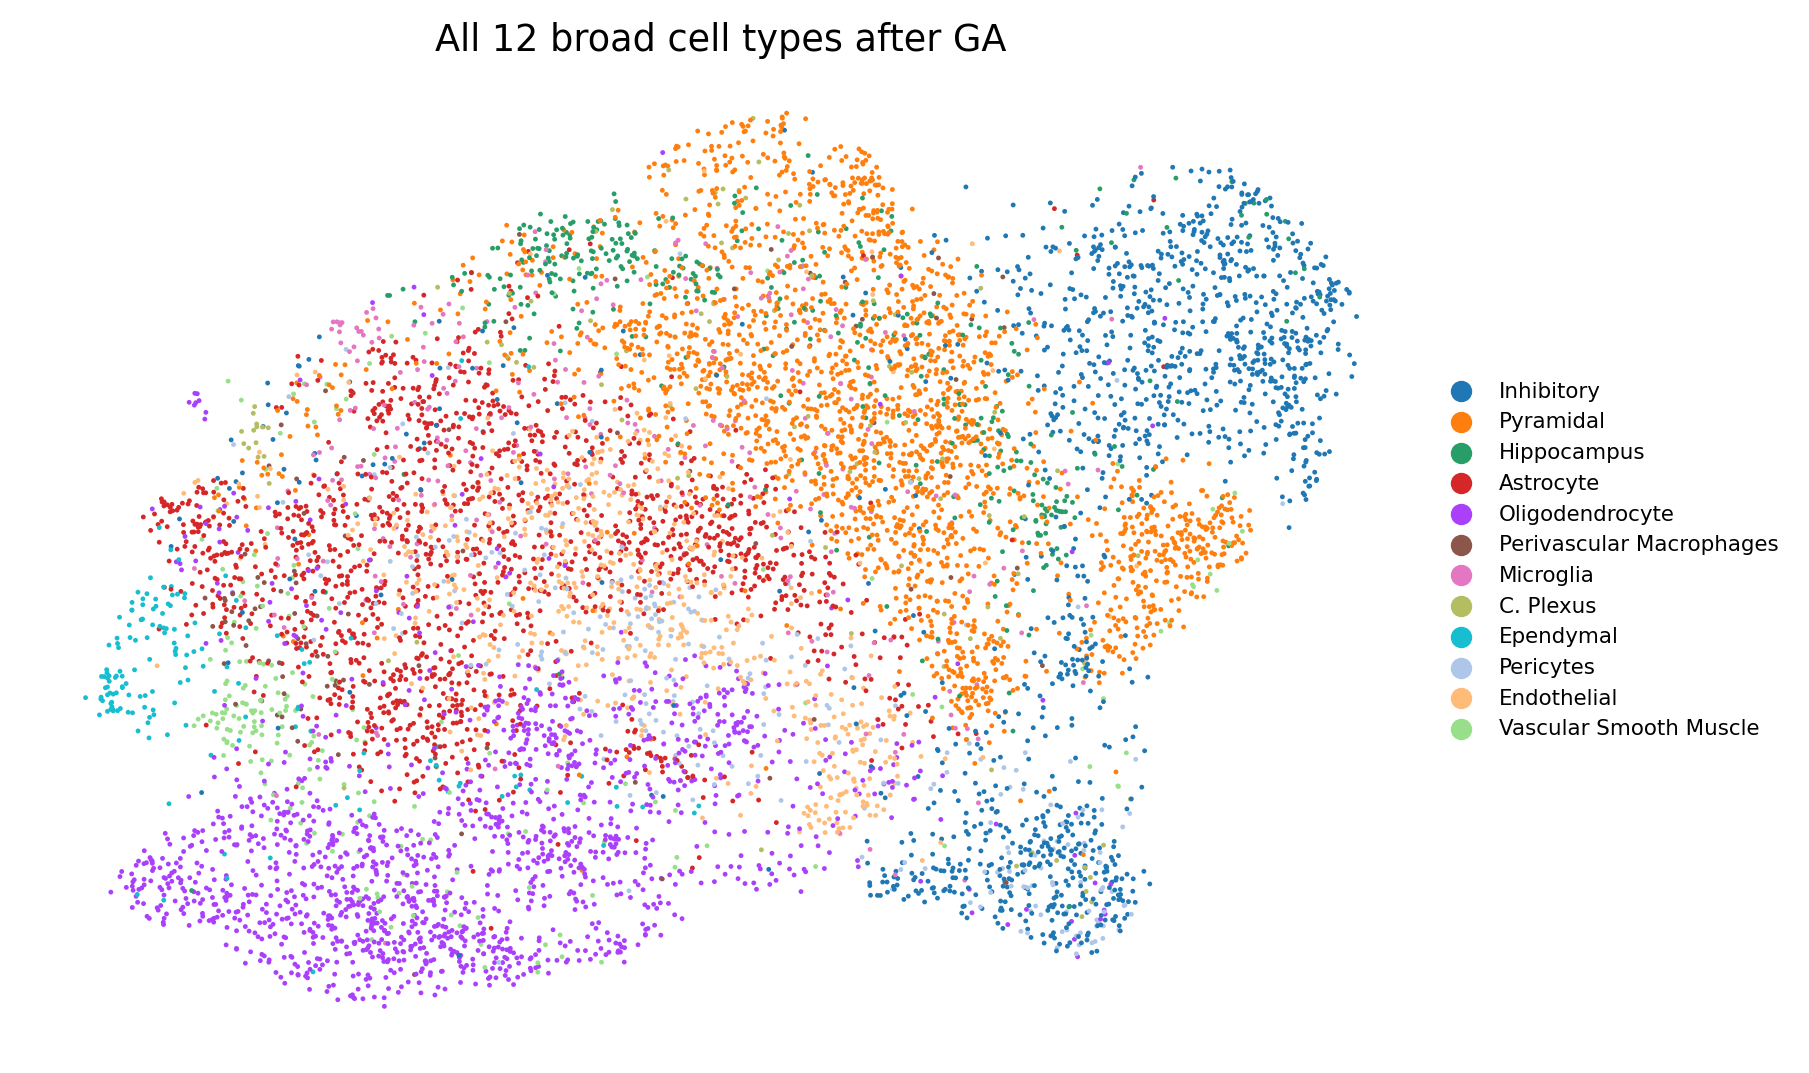

,source,input_observations,sampled_observations,input_genes,genes_after_hvg,max_observations,n_pcs,n_neighbors,seed
0,complete_ga,9056,9056,33,33,10000,30,15,42


,GA cells
Level1,
Inhibitory,1376
Pyramidal,2250
Hippocampus,419
Astrocyte,1559
Oligodendrocyte,1591
Perivascular Macrophages,98
Microglia,298
C. Plexus,108
Ependymal,163


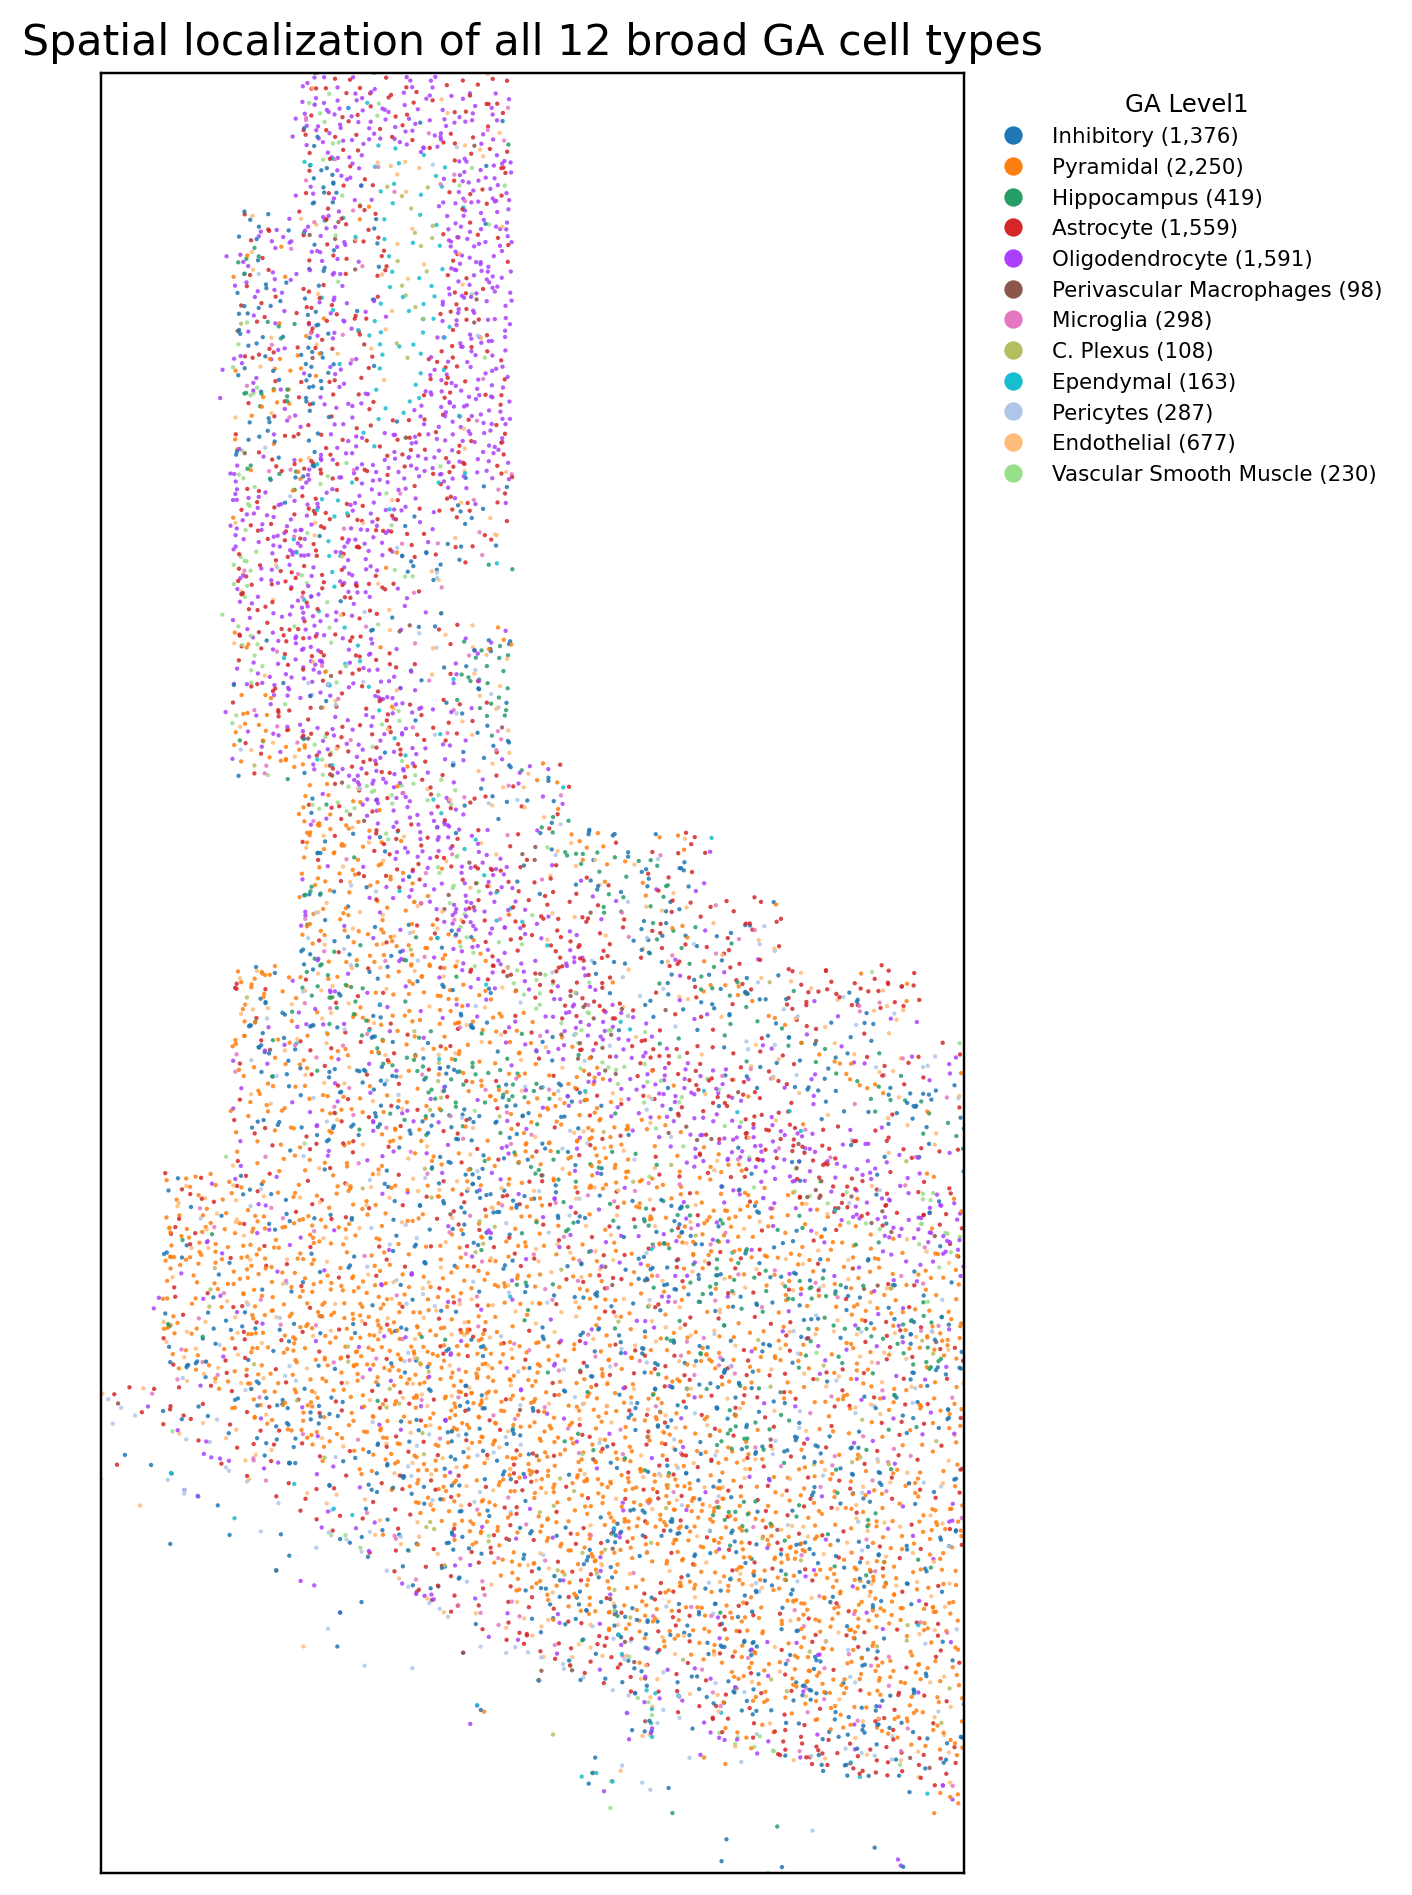

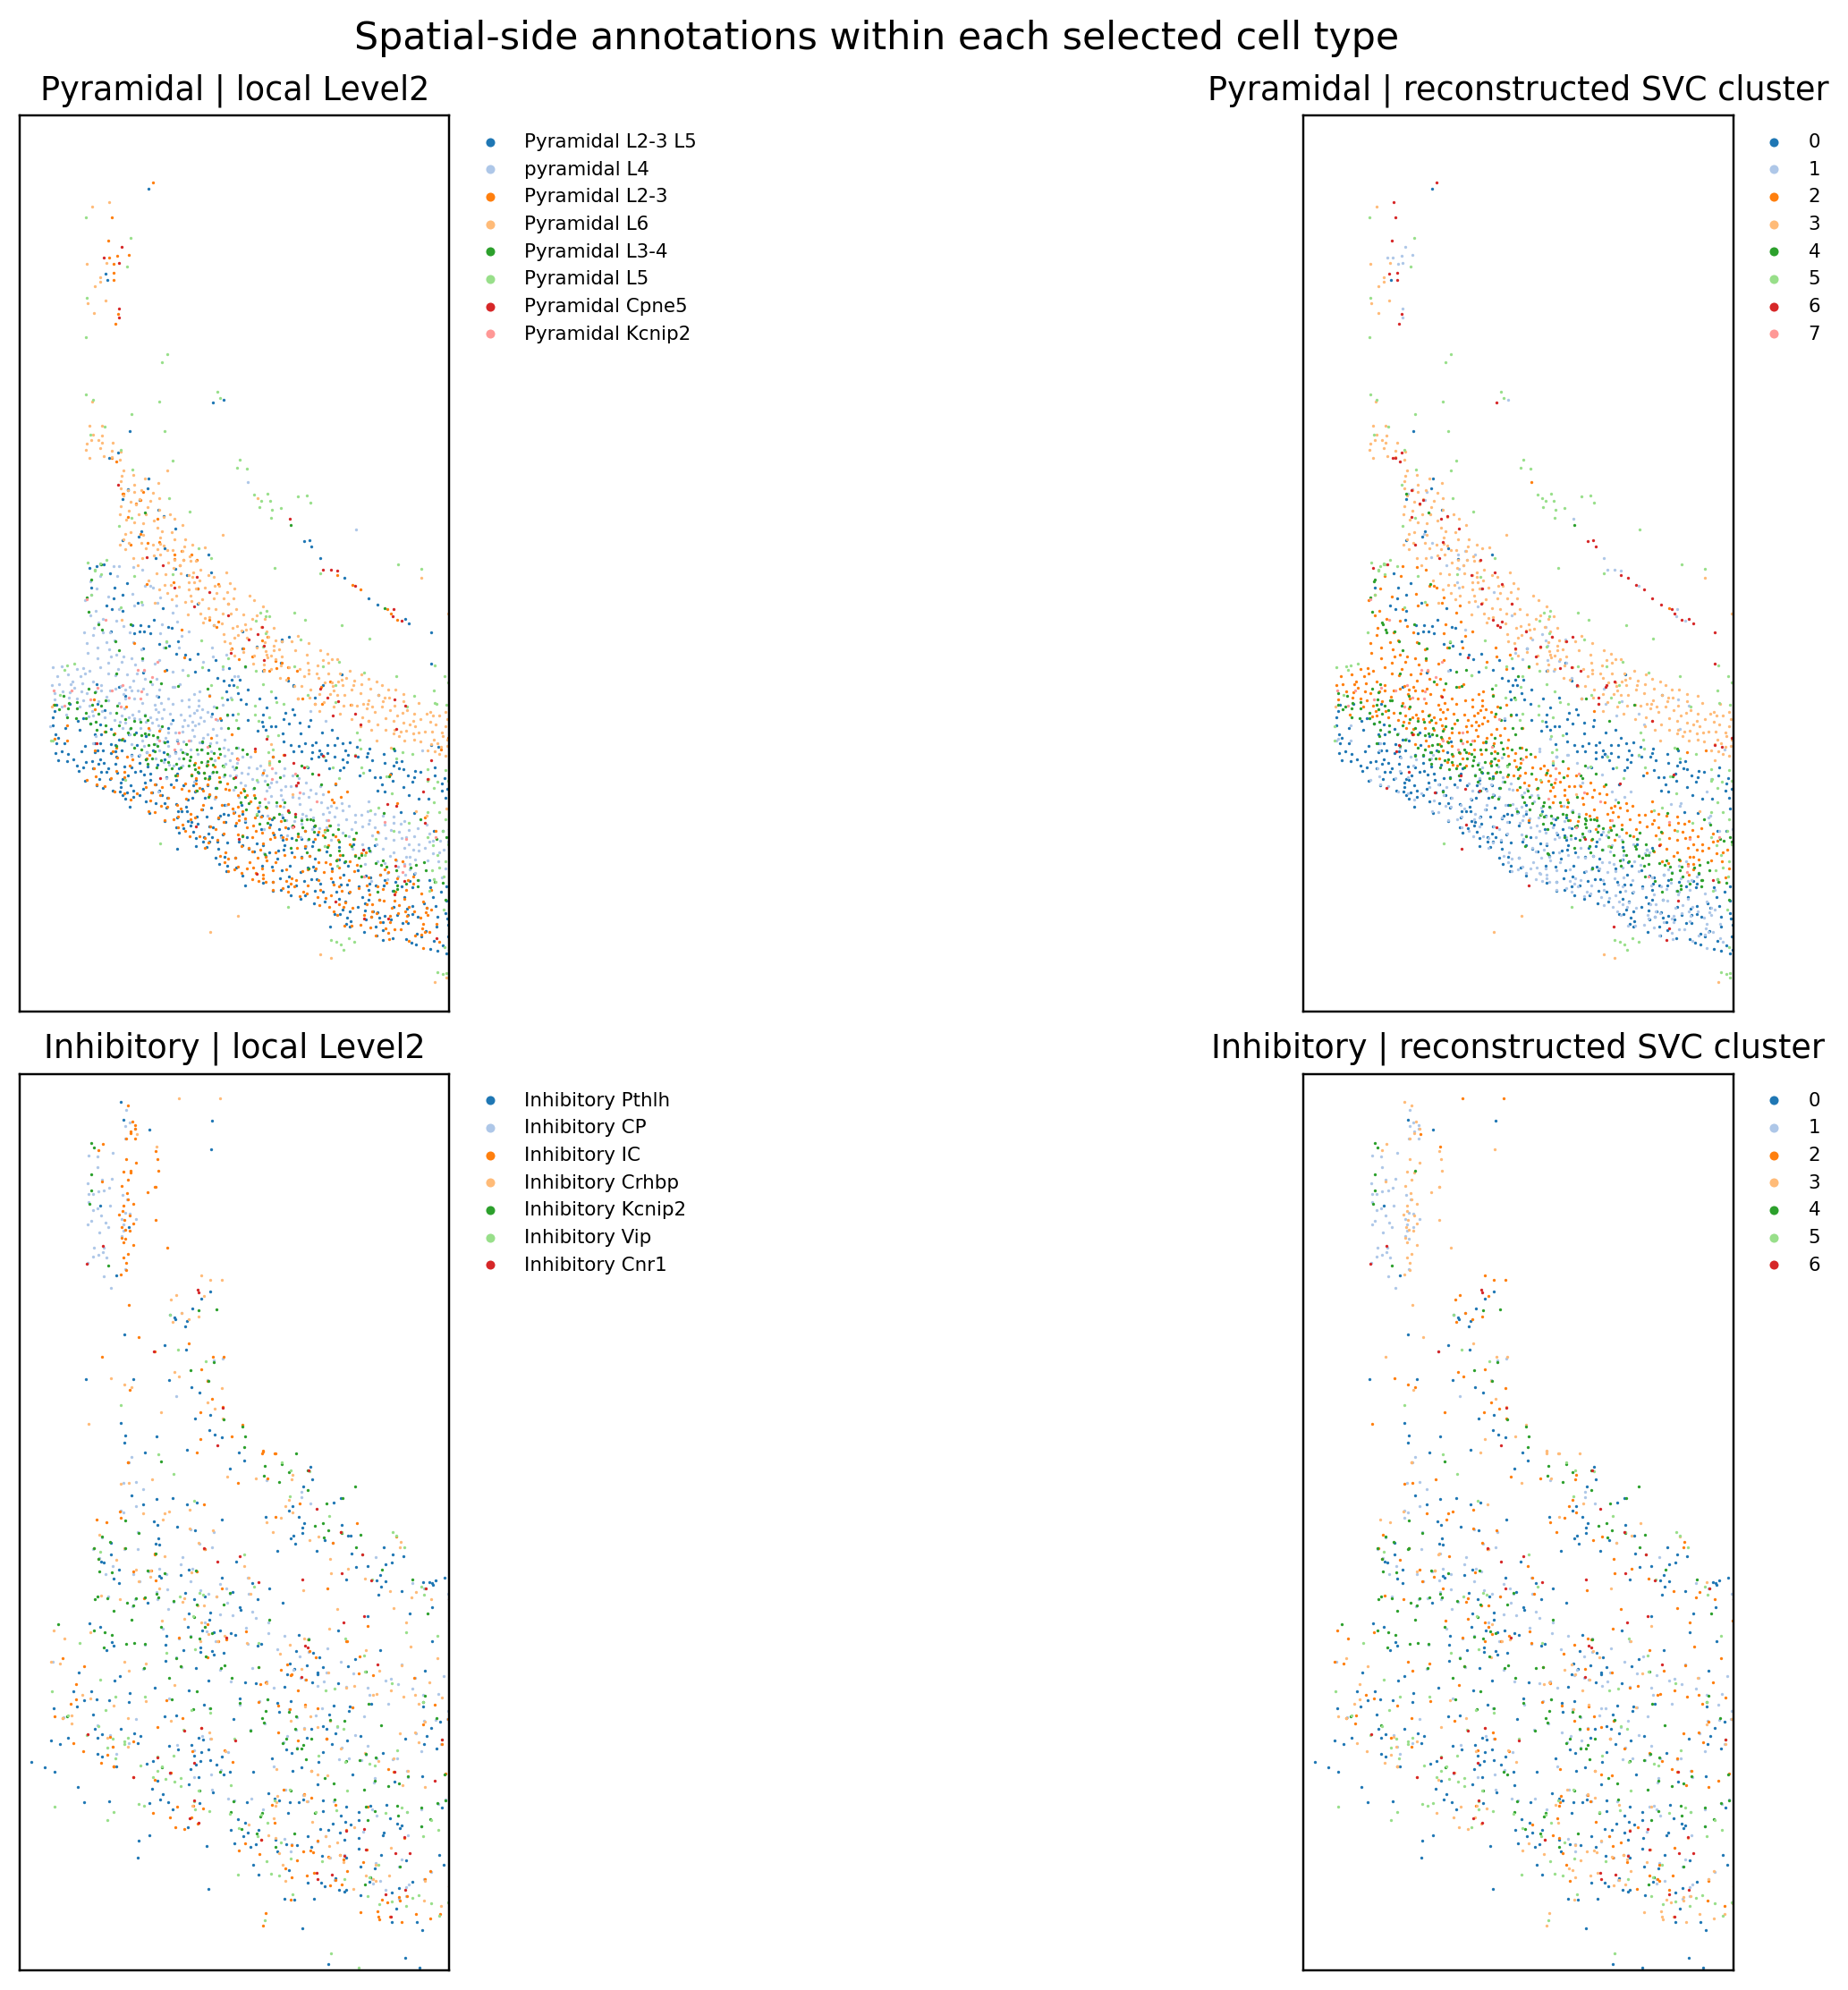

,figure,role
0,/Users/jiaoyifeng/PycharmProjects/REVISE_rebut...,complete 12-class GA expression UMAP
1,/Users/jiaoyifeng/PycharmProjects/REVISE_rebut...,all broad GA cell types in one measured-space map
2,/Users/jiaoyifeng/PycharmProjects/REVISE_rebut...,within-cell-type spatial SVC scatter


In [5]:
import scanpy as sc
from reconstruct import preprocess_data
from revise.application.config import compile_application_config, load_application_yaml
from revise.backend.kernels.ot import OTKernel
from revise.config import ENGINE_DEFAULTS, ROUTES
from revise.utils.deterministic import set_global_seed

config_source, config_document = load_application_yaml(CONFIG_PATH)
app_config = compile_application_config(
    config_document,
    source=config_source,
    cwd=DATA_ROOT,
)
full_spatial, full_reference = preprocess_data(
    raw_st.copy(),
    reference.copy(),
    app_config,
)
assert full_spatial.shape == (9056, 33)
assert full_reference.shape == (4800, 33)
assert full_spatial.obs_names.is_unique
assert full_reference.obs_names.is_unique

route_overrides = ROUTES["application"]["sc-SVC:cluster"].overrides
ga_method = route_overrides["ot"]["ga"]["solver"]
tacco_parameters = route_overrides["sc"]["tacco_annotate"]
confidence_key = ENGINE_DEFAULTS["columns"]["confidence_col"]
unknown_key = ENGINE_DEFAULTS["columns"]["unknown_key"]
assert app_config.ot_method == ga_method == "tacco"
assert tacco_parameters == {"multi_center": 1, "lamb": 0.001}

set_global_seed(app_config.seed)
ga_spatial = OTKernel.annotate(
    full_spatial,
    full_reference,
    method=ga_method,
    annotation_key=app_config.broad_column,
    confidence_key=confidence_key,
    unknown_key=unknown_key,
    **tacco_parameters,
)
broad_order = list(pd.unique(
    full_reference.obs[app_config.broad_column].astype(str)
))
posterior = ga_spatial.obsm[app_config.broad_column]
assert ga_spatial.shape == full_spatial.shape == (9056, 33)
assert ga_spatial.obs_names.equals(full_spatial.obs_names)
assert posterior.shape == (9056, 12)
assert list(map(str, posterior.columns)) == broad_order
assert len(broad_order) == 12
assert set(ga_spatial.obs[app_config.broad_column].astype(str)) == set(broad_order)

selected_spatial = {}
for broad in ("Pyramidal", "Inhibitory"):
    spatial_output = output_paths[broad]["spatial"].copy()
    observed = spatial_output.obs["Level1"].astype(str)
    assert set(observed.unique()) == {broad}
    assert spatial_output.obs_names.isin(raw_st.obs_names).all()
    expected_names = ga_spatial.obs_names[
        ga_spatial.obs["Level1"].astype(str) == broad
    ]
    assert spatial_output.obs_names.equals(expected_names)
    assert np.array_equal(
        np.asarray(spatial_output.obsm["spatial"]),
        np.asarray(ga_spatial[expected_names].obsm["spatial"]),
    )
    selected_spatial[broad] = spatial_output

selected_names = pd.Index([])
for spatial_output in selected_spatial.values():
    assert selected_names.intersection(spatial_output.obs_names).empty
    selected_names = selected_names.append(spatial_output.obs_names)

ga_umap = independent_umap(
    ga_spatial,
    categorical_labels=ga_spatial.obs["Level1"],
    source_name="complete_ga",
)
assert ga_umap.n_obs == ga_spatial.n_obs == 9056
broad_palette = [
    "#1f77b4", "#ff7f0e", "#279e68", "#d62728",
    "#aa40fc", "#8c564b", "#e377c2", "#b5bd61",
    "#17becf", "#aec7e8", "#ffbb78", "#98df8a",
]
broad_colors = dict(zip(broad_order, broad_palette))
ga_umap.obs["Level1"] = pd.Categorical(
    ga_umap.obs["Level1"].astype(str),
    categories=broad_order,
    ordered=True,
)

fig, ax = plt.subplots(figsize=(8.2, 5.8))
sc.pl.umap(
    ga_umap,
    color="Level1",
    palette=[broad_colors[label] for label in broad_order],
    size=10,
    title="All 12 broad cell types after GA",
    legend_fontsize=7,
    frameon=False,
    ax=ax,
    show=False,
)
GA_UMAP_PATH = DATA_ROOT / "figures/osmFISH_GA_all_broad_umap.png"
GA_UMAP_PATH.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(GA_UMAP_PATH, dpi=220, bbox_inches="tight")
display(Image(filename=str(GA_UMAP_PATH)))
plt.close(fig)
display(pd.DataFrame([ga_umap.uns["independent_umap_contract"]]))
ga_counts = (
    ga_spatial.obs["Level1"].astype(str).value_counts().reindex(broad_order)
)
display(ga_counts.rename("GA cells").to_frame())

background = np.asarray(ga_spatial.obsm["spatial"])
x_limits = (float(background[:, 0].min()), float(background[:, 0].max()))
y_limits = (float(background[:, 1].min()), float(background[:, 1].max()))

from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(7.5, 8.5), constrained_layout=True)
ga_labels = ga_spatial.obs["Level1"].astype(str).to_numpy()
point_colors = np.asarray([broad_colors[label] for label in ga_labels])
ax.scatter(
    background[:, 0],
    background[:, 1],
    s=2.0,
    c=point_colors,
    alpha=0.85,
    linewidths=0,
    rasterized=True,
)
legend_handles = [
    Line2D(
        [0], [0], marker="o", linestyle="", color=broad_colors[broad],
        markersize=5, label=f"{broad} ({ga_counts.loc[broad]:,})",
    )
    for broad in broad_order
]
ax.legend(
    handles=legend_handles,
    bbox_to_anchor=(1.01, 1),
    loc="upper left",
    frameon=False,
    fontsize=7,
    title="GA Level1",
    title_fontsize=8,
)
ax.set_title("Spatial localization of all 12 broad GA cell types", fontsize=14)
ax.set_xlim(x_limits)
ax.set_ylim(y_limits)
ax.set_aspect("equal", adjustable="box")
ax.set_xticks([])
ax.set_yticks([])
GA_SCATTER_PATH = DATA_ROOT / "figures/osmFISH_GA_all_broad_scatter.png"
fig.savefig(GA_SCATTER_PATH, dpi=220, bbox_inches="tight")
display(Image(filename=str(GA_SCATTER_PATH)))
plt.close(fig)

fig, axes = plt.subplots(2, 2, figsize=(13, 10), constrained_layout=True)
selected_order = ["Pyramidal", "Inhibitory"]
for row, broad in enumerate(selected_order):
    spatial_output = selected_spatial[broad]
    coords = np.asarray(spatial_output.obsm["spatial"])
    for column, key in enumerate(("Level2", "SVC_cluster")):
        ax = axes[row, column]
        labels = spatial_output.obs[key].astype(str)
        if key == "SVC_cluster":
            categories = sorted(labels.unique(), key=int)
        else:
            categories = labels.value_counts().index.tolist()
        palette = plt.get_cmap("tab20").colors
        for index, label in enumerate(categories):
            selected = labels.to_numpy() == label
            ax.scatter(
                coords[selected, 0],
                coords[selected, 1],
                s=1.2,
                color=palette[index % len(palette)],
                label=label,
                linewidths=0,
                rasterized=True,
            )
        title = "local Level2" if key == "Level2" else "reconstructed SVC cluster"
        ax.set_title(f"{broad} | {title}")
        ax.set_xlim(x_limits)
        ax.set_ylim(y_limits)
        ax.set_aspect("equal", adjustable="box")
        ax.set_xticks([])
        ax.set_yticks([])
        ax.legend(
            bbox_to_anchor=(1.01, 1),
            loc="upper left",
            frameon=False,
            fontsize=7,
            markerscale=3,
        )
fig.suptitle("Spatial-side annotations within each selected cell type", fontsize=14)
SVC_SCATTER_PATH = DATA_ROOT / "figures/osmFISH_by_cell_type_SVC_scatter.png"
fig.savefig(SVC_SCATTER_PATH, dpi=220, bbox_inches="tight")
display(Image(filename=str(SVC_SCATTER_PATH)))
plt.close(fig)

display(pd.DataFrame({
    "figure": [GA_UMAP_PATH, GA_SCATTER_PATH, SVC_SCATTER_PATH],
    "role": [
        "complete 12-class GA expression UMAP",
        "all broad GA cell types in one measured-space map",
        "within-cell-type spatial SVC scatter",
    ],
}))


## Interpretation boundary

TonT segmentation and the recovered-cell reference come from the same osmFISH
case, and the TonT segmentation itself is guided by TACCO annotations from that
reference. The overview UMAP and merged spatial map contain all 12 broad labels
predicted by the exact global-anchoring stage; the Pyramidal and Inhibitory detail panels come from two
separately published sc-SVC runs and their spatial/expression outputs are not
observation-paired. These panels demonstrate an executable same-case workflow,
not an independent benchmark or biological validation of REVISE.
